In [1]:
print("IRIS FLOWER CLASSIFICATION")

IRIS FLOWER CLASSIFICATION


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [12]:
df = pd.read_csv("IRIS.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [13]:
print(df.shape)
df.info()
df.isnull().sum()

(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


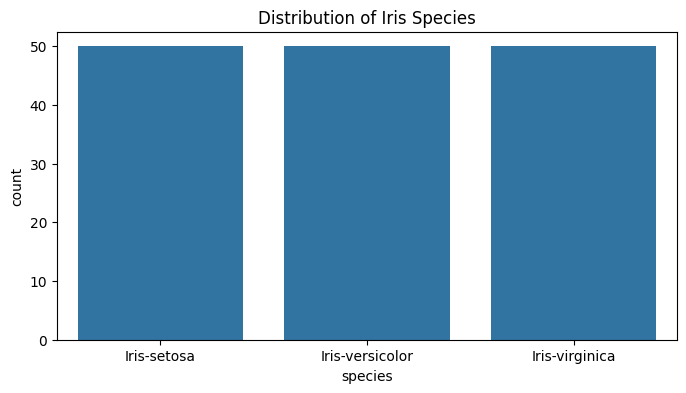

In [14]:
plt.figure(figsize=(8,4))
sns.countplot(
    x="species",
    data=df
)
plt.title("Distribution of Iris Species")
plt.show()

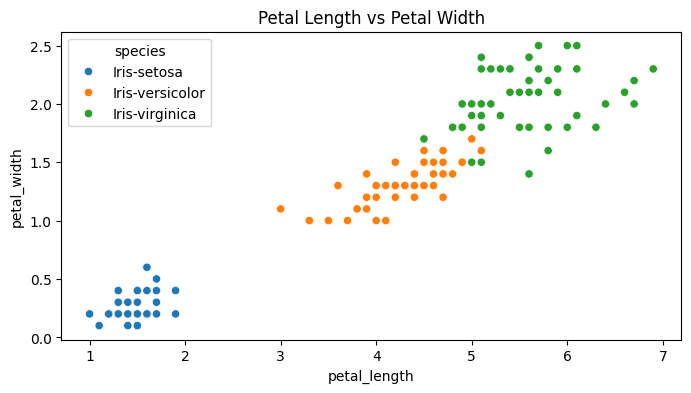

In [15]:
plt.figure(figsize=(8,4))
sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species"
)
plt.title("Petal Length vs Petal Width")
plt.show()

In [16]:
encoder = LabelEncoder()
df["species"] = encoder.fit_transform(
    df["species"]
)

In [17]:
X = df.drop(
    "species",
    axis=1
)
y = df["species"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(
    X_train,
    y_train
)
print("Model Trained Successfully")

Model Trained Successfully


In [20]:
predictions = model.predict(X_test)

In [21]:
accuracy = accuracy_score(
    y_test,
    predictions
)
print("Accuracy:", accuracy)

Accuracy: 1.0


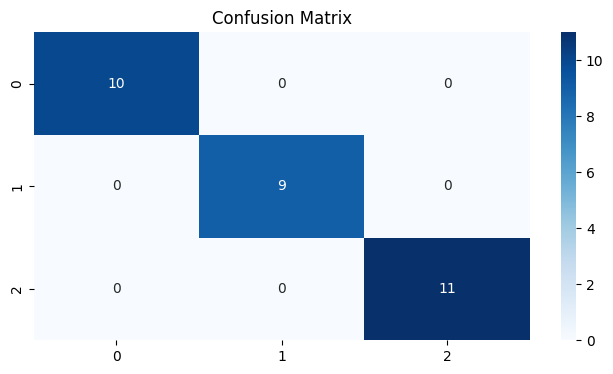

In [23]:
cm = confusion_matrix(
    y_test,
    predictions
)
plt.figure(figsize=(8,4))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)
plt.title("Confusion Matrix")
plt.show()

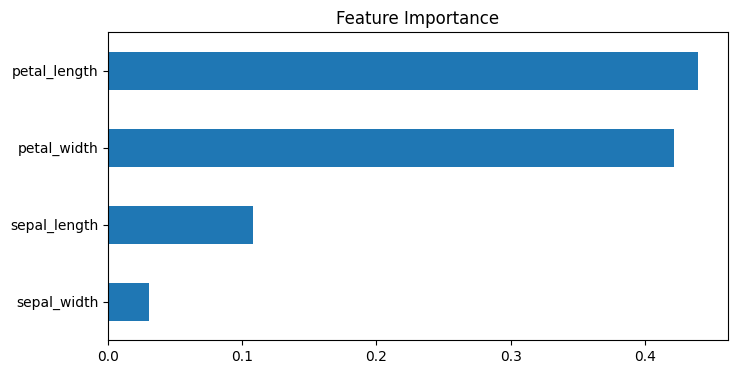

In [24]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)
importance.sort_values().plot(
    kind="barh",
    figsize=(8,4)
)
plt.title("Feature Importance")
plt.show()

In [25]:
print("""The Random Forest Classifier was used
to classify Iris flowers into Setosa,
Versicolor and Virginica species based
on sepal and petal measurements.
The model achieved high classification
accuracy, showing that machine learning
can effectively identify flower species.""")

The Random Forest Classifier was used
to classify Iris flowers into Setosa,
Versicolor and Virginica species based
on sepal and petal measurements.
The model achieved high classification
accuracy, showing that machine learning
can effectively identify flower species.
